# Imports

## General imports

In [1]:
import os
from matplotlib import pyplot as plt
import numpy as np
import pickle
from importlib import reload
import time

## Specialized imports

In [2]:
from common.baseclasses import AWA # https://github.com/asmcleod/common.git
from common.misc import flatten
from common import numerical_recipes as numrec
from NearFieldOptics import Materials as M # https://github.com/asmcleod/NearFieldOptics.git
from NearFieldOptics.Materials import material_types,TransferMatrixMedia
# from mnOPSuite.PRISM.python import scandelay_FTIR as sd # https://github.com/mnop-laboratory/mnOPSuite.git

<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "Bi2Se3_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "PMMA_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "sio2_300nm_extracted_epsilon_cone_A=2a.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "TaS2_eps_230K.csv"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "TaS2_eps_30K.csv"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "Erik_BSTS_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "VO2_295K.csv"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "VO2_360K.csv"...
<material_types.Ta

## Tools for inversion

In [3]:
import ProbeCavityEigenfields as PCE # https://github.com/asmcleod/ProbeCavityEigenfields.git
from ProbeCavityEigenfields import RotationalMoM as RotMOM
from ProbeCavityEigenfields import ProbeSpectroscopy as PS
from ProbeCavityEigenfields import EigenInversion as EI 

<plotting>:
	Registered colormaps "Warm" and "Warm_r"...
<plotting>:
	Registered colormaps "vanheum" and "vanheum_r"...
<plotting>:
	Registered colormaps "NT-MDT" and "NT-MDT_r"...
<plotting>:
<plotting>:
	Registered colormaps "jingdi" and "jingdi_r"...
<plotting>:
	Registered colormaps "Halcyon" and "Halcyon_r"...
<plotting>:
	Registered colormaps "Cold" and "Cold_r"...
<plotting>:
	Registered colormaps "Sky" and "Sky_r"...
<plotting>:
	Registered colormaps "Gwyddion.net" and "Gwyddion.net_r"...
<plotting>:
	Registered colormaps "BlueRed" and "BlueRed_r"...
<plotting>:
	Registered colormaps "vanheum3" and "vanheum3_r"...
<plotting>:
	Registered colormaps "vanheum2" and "vanheum2_r"...


<module 'ProbeCavityEigenfields.EigenInversion' from '/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/EigenInversion.py'>

# Initialize simulation parameters

In [20]:
sim_kwargs=dict(a_nm=10,
                gapmin_nm=1,
                amplitude_nm=50,
                Ngaps=96/2,
               Nmodes=20) # We can change these later as we like

# Load Probe and build/load its tools for simulation

## Load probe

Attemping to load from file "/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"...
Could not add probe to `ProbesCollection.` 
A probe named "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244" is already instantiated!  If you wish to overwrite this probe, remove it from the collection of probes by using the `del` command!
You may avert this error by passing keyword `overwrite=True` to `load`!
Successfully loaded from file "/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"!


(-2e-06, 1.4e-05)

<Figure size 640x480 with 0 Axes>

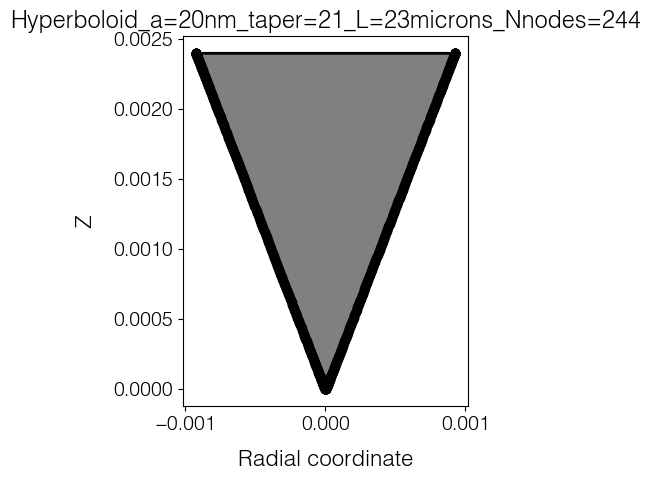

<Figure size 640x480 with 0 Axes>

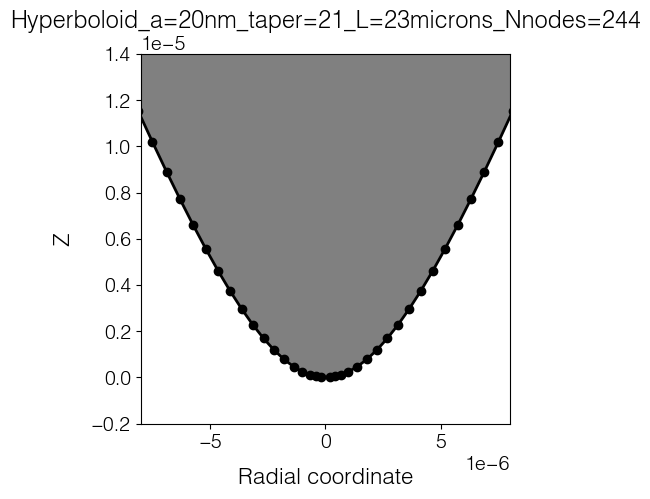

In [10]:
# Pickle files associated with probe "Hyperboloid=20nm_L=23microns_Nnodes=488" or "hyperboloid" should be distributed with this notebook
# But other probes can be used or generated.
# Take the files labeled 'hyperboloid' and place in `ProbeCavityEigenfields/Probe models`

# The probes that works best have their ProbeGapSpectroscopy with a basis gap of ~tip radius
#probe_name = 'Cone_a=20nm_taper=21_L=23microns_Nnodes=244'  
probe_name = 'Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244'  
#probe_name = 'Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=488' # Slow

Probe=P=PCE.load(probe_name,PCE.Probe)
a = Probe.get_a()

plt.figure()
P.plot_geometry()

plt.figure()
P.plot_geometry()
window=8
plt.xlim(-window/2*a,+window/2*a)
plt.ylim(-a,(window-1)*a)


## Load / recompute ProbeGapSpectroscopy

Attemping to load from file "/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_ProbeGapSpectroscopy.pickle"...
Could not add probe to `ProbesCollection.` 
A probe named "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244" is already instantiated!  If you wish to overwrite this probe, remove it from the collection of probes by using the `del` command!
You may avert this error by passing keyword `overwrite=True` to `load`!
Could not add probe to `ProbesCollection.` 
A probe named "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244" is already instantiated!  If you wish to overwrite this probe, remove it from the collection of probes by using the `del` command!
You may avert this error by passing keyword `overwrite=True` to `load`!
Successfully loaded from file "/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_ProbeGapSpectroscopy.pickle"

Text(0.5, 1.0, 'Eigenmode Brightness from ProbeGapSpectroscopy')

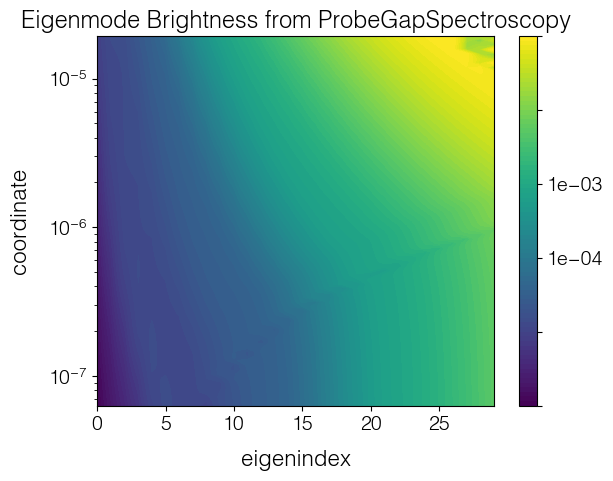

In [12]:
#-- Build/load Probe gap spectroscopy

recompute=True
overwrite=False

try:
    if recompute: raise OSError
    ProbeGapSpectroscopy = PCE.load(probe_name,PS.ProbeGapSpectroscopyParallel)
except OSError:
    print('Recomputing Probe Gap Spectroscopy...')

    a=P.get_a()
    gap0 = a/5 # This is key.  Unless Nmodes is large, and unless basis gap has high spatial frequency content, we can't adequately describe SiC.
    gapmin=a/100; gapmax=a*50
    gaps,_=numrec.GetQuadrature(xmin=gapmin,xmax=gapmax*2,N=144*2,quadrature=numrec.TS)
    gaps=gaps[:len(gaps)//2] # Take bottom half of quadrature points; the top half is very dense at large values which is useless
    
    ProbeGapSpectroscopy = PS.ProbeGapSpectroscopyParallel(Probe, gaps=gaps, \
                                                         ncpus=8, backend='multiprocessing', \
                                                         Nmodes=50, sommerfeld=False,
                                                         basis_gap=gap0,
                                                         reversed=False)  
        
    print('Min gapsize/a in spectroscopy:',ProbeGapSpectroscopy.get_coords().min()/P.get_a())
    print('Max gapsize/a in spectroscopy:',ProbeGapSpectroscopy.get_coords().max()/P.get_a())
    print('N gaps in spectroscpy:',len(ProbeGapSpectroscopy.get_coords()))
    
    save_gapspectroscopy=False
    overwrite_gapspectroscopy=True
    
    #--- Classify eigenfields and find range of good modes
    Nmodes_classify=sim_kwargs['Nmodes']
    ProbeGapSpectroscopy(Nmodes=Nmodes_classify,reversed=False,by_rho=True,debug=False,coordmax=10*P.get_a())
    eigenrhos = ProbeGapSpectroscopy.get_eigenrhos_AWA()
    eigencharges = ProbeGapSpectroscopy.get_eigencharges_AWA()
    ProbeGapSpectroscopy.plot_eigenrhos(Nmodes=Nmodes_classify)
    
    try: PCE.save(ProbeGapSpectroscopy,overwrite=overwrite_gapspectroscopy)
    except OSError: pass

#--- Plot brightness, how many modes are good?
angles=np.linspace(10,90,20)
all_vs = ProbeGapSpectroscopy.get_eigenbrightness_AWA(angles=angles,verbose=True)
plt.figure()
np.abs(all_vs).plot(plotter=plt.contourf,log_scale=True)
plt.gca().set_yscale('log')
plt.title('Eigenmode Brightness from ProbeGapSpectroscopy')

## Load / recompute EncodedEigenfields

In [13]:
#-- Build/load encoded eigenfields

recompute=False
overwrite=False

try:
    if recompute: raise OSError
    EE = PCE.load(probe_name,PS.EncodedEigenfields)
except OSError:
    print('Recomputing Encoded Eigenfields...')
    gap0 = P.get_a()/5 # This is key.  Unless Nmodes is large, and unless basis gap has high spatial frequency content, we can't adequately describe SiC.
    EE = PS.EncodedEigenfields(ProbeGapSpectroscopy,gap0=gap0, Nmodes=sim_kwargs['Nmodes'],
                                kappa_min=None, kappa_max=10/P.get_a(),
                                Nkappas=244*4, qquadrature=PCE.numrec.GL)
    try: PCE.save(EE,overwrite=overwrite)
    except OSError: pass

Attemping to load from file "/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_EncodedEigenfields.pickle"...
Attemping to load from file "/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"...
Could not add probe to `ProbesCollection.` 
A probe named "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244" is already instantiated!  If you wish to overwrite this probe, remove it from the collection of probes by using the `del` command!
You may avert this error by passing keyword `overwrite=True` to `load`!
Successfully loaded from file "/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"!
Successfully loaded from file "/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_

## Load / recompute InvertibleEigenfields

In [21]:
#-- Build invertible eigenfields

recompute=True
overwrite=True

try:
    if recompute: raise OSError
    IE = PCE.load(probe_name,PS.InvertibleEigenfields)
except OSError:
    print('Recomputing Invertible Eigenfields...')
    IE = PS.InvertibleEigenfields(ProbeGapSpectroscopy, Nmodes=sim_kwargs['Nmodes'],
                                interpolation='quadratic',bounds_error=False,fill_value='extrapolate')
    try: PCE.save(IE,overwrite=overwrite)
    except OSError: pass

Recomputing Invertible Eigenfields...
Successfully saved to file "/Users/alexandersmcleod/tools/python/ProbeCavityEigenfields/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_InvertibleEigenfields.pickle"!


## Compare simulation methods

For modestly demanding simulations, ensure they all converge to the same result

amplitude= 9.999999999999999e-06
gapmin= 2e-07
<ProbeCavityEigenfields.Probe.EradVsGap>:
	Computing response for 48 gaps at freq=750.0970568971655...
<ProbeCavityEigenfields.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<ProbeCavityEigenfields.Probe.EradVsGap>:
	Computing response for 48 gaps at freq=758.7188621488572...
<ProbeCavityEigenfields.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<ProbeCavityEigenfields.Probe.EradVsGap>:
	Computing response for 48 gaps at freq=767.3406674005487...
<ProbeCavityEigenfields.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<ProbeCavityEigenfields.Probe.EradVsGap>:
	Computing response for 48 gaps at freq=775.9624726522402...
<ProbeCavityEigenfields.Probe.getFourPotentialPropagators>:
	Computing field propagators at k=0...
	Including evane

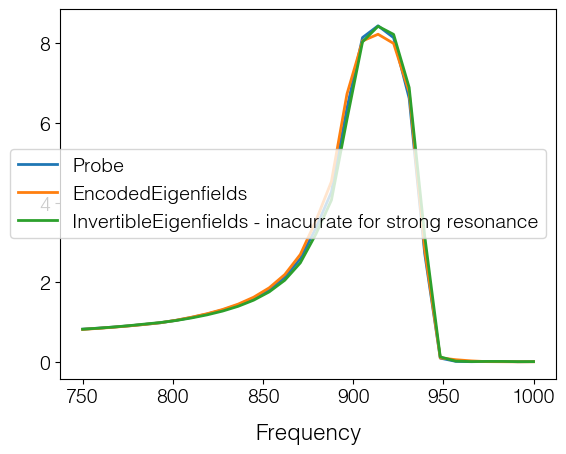

In [23]:
do_compare=True

if do_compare:

    freqs=np.linspace(750,1000,30)
    material=M.SiC_6H
    #material=M.SiO2_300nm
    #material=M.PMMA
    beta = material.reflection_p(freqs,q=1/30e-7)
    
    T=PCE.Timer()
    signals = P.getNormalizedSignal(freqs,rp=material.reflection_p,rp_norm=M.Au.reflection_p,
                                    Nkappas=244,kappa_max=10/P.get_a(),**sim_kwargs)
    np.abs(signals['Sn_norm'][3]).plot(label='Probe')
    print('---- Probe calculator: ----')
    print(T())
    print()
    
    
    T=PCE.Timer()
    signals_EE = EE.getNormalizedSignal(freqs,rp=material.reflection_p,rp_norm=M.Au.reflection_p,
                                    **sim_kwargs)
    np.abs(signals_EE['Sn_norm'][3]).plot(label='EncodedEigenfields')
    print('---- EncodedEigenfields calculator: ----')
    print(T())
    print()

    T=PCE.Timer()
    signals_IE = IE.getNormalizedSignal(beta=beta,beta_norm=[1]*len(beta),
                                    **sim_kwargs)
    np.abs(signals_IE['Sn_norm'][3]).plot(label='InvertibleEigenfields')
    print('---- InvertibleEigenfields calculator: ----')
    print(T())
    print()
    
    plt.legend()

It should now be clear that we can use `InvertibleEigenfields` to make accurate predictions in all cases where dipsersion can be negletcted in the reflection coefficient (e.g. for bulk media, like half-spaces of silicon or gold).

# Simulate how contrast between Si/Au varies with tapping amplitude

In [150]:
zs,dzs=numrec.GetQuadrature(xmin=1*10**-1.5,xmax=100,N=144,quadrature=numrec.GL)
zs=zs[:len(zs)//2]
zs = zs/zs.max()*30
print(len(zs))

96


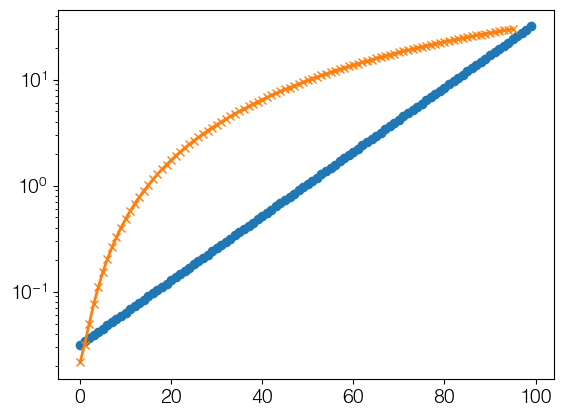

In [151]:
plt.plot(ProbeGapSpectroscopy.get_coords()/a,marker='o')

plt.plot(zs,marker='x')

plt.gca().set_yscale('log')

In [102]:
# Identify the maximum tapping amplitude, above which we cannot make reliable predictions
amplitude_max_rel_a = np.array(IE.Rs.axis_limits[0]).max()
amplitude_max_nm = amplitude_max_rel_a * sim_kwargs['a_nm']/Probe.get_a()

amplitudes_nm = np.linspace(.5,amplitude_max_nm,50)
amplitudes_rel_a = amplitudes_nm/sim_kwargs['a_nm']

q0=1/(sim_kwargs['a_nm']*1e-7)
freq=1000
beta_Si = M.Si.reflection_p(freq,q0)
beta_Au = 1

sim_kwargs['Ngaps']=96 #
sim_kwargs['Nmodes']=30 #
IE = PS.InvertibleEigenfields(ProbeGapSpectroscopy, Nmodes=sim_kwargs['Nmodes'],
                            interpolation='quadratic',bounds_error=False,fill_value='extrapolate')

harmonics=[1,2,3]
s3_vals_Au_vs_Si=[]
s3divs2_vals_Au=[]
s3divs2_vals_Si=[]

for amplitude_nm in amplitudes_nm:
    sim_kwargs['amplitude_nm']=amplitude_nm

    signals_Au_vs_Si = IE.getNormalizedSignal(beta=beta_Si,beta_norm=beta_Au,
                           **sim_kwargs)
    s3_vals_Au_vs_Si.append( [complex(signals_Au_vs_Si['Sn_norm'][n]) for n in harmonics] )
    
    signals_Si = IE.getNormalizedSignal(beta=beta_Si,beta_norm=None,
                           **sim_kwargs)
    s3divs2_vals_Si.append( complex(signals_Si['Sn'][3]) / complex(signals_Si['Sn'][2]) )
    
    signals_Au = IE.getNormalizedSignal(beta=beta_Au,beta_norm=None,
                           **sim_kwargs)
    s3divs2_vals_Au.append( complex(signals_Au['Sn'][3]) / complex(signals_Au['Sn'][2]) )

s3_vals_Au_vs_Si = AWA(s3_vals_Au_vs_Si,
                       axes=[amplitudes_rel_a,harmonics],
                       axis_names=['Tapping amplitude (rel. a)','Harmonic'])

s3divs2_vals_Si = AWA(s3divs2_vals_Si,
                       axes=[amplitudes_rel_a],
                       axis_names=['Tapping amplitude (rel. a)'])

s3divs2_vals_Au = AWA(s3divs2_vals_Au,
                       axes=[amplitudes_rel_a],
                       axis_names=['Tapping amplitude (rel. a)'])

amplitude= 1e-07
gapmin= 2e-07
amplitude= 1e-07
gapmin= 2e-07
amplitude= 1e-07
gapmin= 2e-07
amplitude= 4.921281246108592e-07
gapmin= 2e-07
amplitude= 4.921281246108592e-07
gapmin= 2e-07
amplitude= 4.921281246108592e-07
gapmin= 2e-07
amplitude= 8.842562492217183e-07
gapmin= 2e-07
amplitude= 8.842562492217183e-07
gapmin= 2e-07
amplitude= 8.842562492217183e-07
gapmin= 2e-07
amplitude= 1.2763843738325772e-06
gapmin= 2e-07
amplitude= 1.2763843738325772e-06
gapmin= 2e-07
amplitude= 1.2763843738325772e-06
gapmin= 2e-07
amplitude= 1.6685124984434366e-06
gapmin= 2e-07
amplitude= 1.6685124984434366e-06
gapmin= 2e-07
amplitude= 1.6685124984434366e-06
gapmin= 2e-07
amplitude= 2.0606406230542955e-06
gapmin= 2e-07
amplitude= 2.0606406230542955e-06
gapmin= 2e-07
amplitude= 2.0606406230542955e-06
gapmin= 2e-07
amplitude= 2.4527687476651545e-06
gapmin= 2e-07
amplitude= 2.4527687476651545e-06
gapmin= 2e-07
amplitude= 2.4527687476651545e-06
gapmin= 2e-07
amplitude= 2.844896872276014e-06
gapmin= 2e-07
am

Text(0.5, 0, '$a$ (nm)')

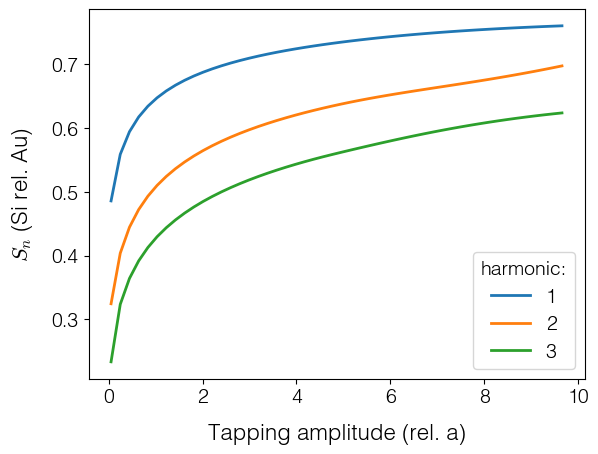

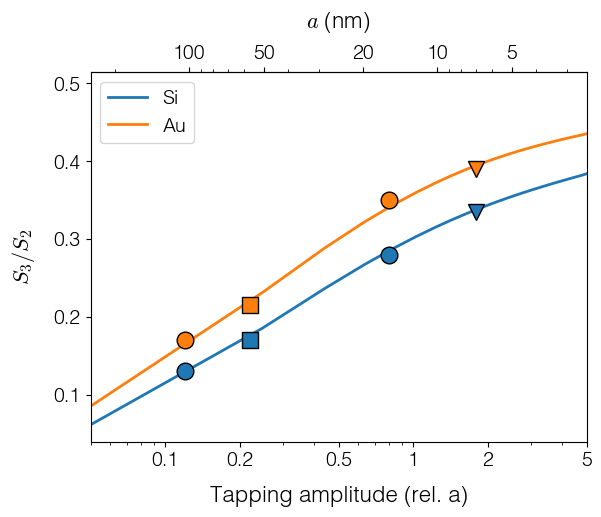

In [121]:
plt.figure()
for n in harmonics:
    l,=np.abs(s3_vals_Au_vs_Si.cslice[:,n]).plot(label=n)
plt.legend(title='harmonic:')
plt.ylabel('$S_n$ (Si rel. Au)')

plt.figure()
l1,=np.abs(s3divs2_vals_Si).plot(label='Si')
l2,=np.abs(s3divs2_vals_Au).plot(label='Au')
plt.ylabel('$S_3/S_2$')
plt.legend()
#plt.yticks([.3,.35,.4,.45,.5])

#plt.twinx()
#np.abs(s3divs2_vals_Si/s3divs2_vals_Au).plot(color='r')

# These are data from "2025.07.18 - Alex - Si-Au nanoFTIR spectroscopy for FreqDepNorm - Tabletop" for sharp PtSi probe
A_norm = 1.8
plt.plot([A_norm],[.335],color=l1.get_color(),marker='v',markeredgecolor='k',ms=12)
plt.plot([A_norm],[.39],color=l2.get_color(),marker='v',markeredgecolor='k',ms=12)


A_norm = .8
plt.plot([A_norm],[.28],color=l1.get_color(),marker='o',markeredgecolor='k',ms=12)
plt.plot([A_norm],[.35],color=l2.get_color(),marker='o',markeredgecolor='k',ms=12)

# These are data from "2025.07.18 - Alex - Si-Au nanoFTIR spectroscopy for FreqDepNorm - Tabletop" for blunt PtIr probe
A_norm = .12
plt.plot([A_norm],[.13],color=l1.get_color(),marker='o',markeredgecolor='k',ms=12)
plt.plot([A_norm],[.17],color=l2.get_color(),marker='o',markeredgecolor='k',ms=12)


# These are data from "2025.08.22 - Alex - Si-Au multichannel nanoFTIR spectroscopy for FreqDepNorm" for bluntish PtSi probe
A_norm = .22
plt.plot([A_norm],[.17],color=l1.get_color(),marker='s',markeredgecolor='k',ms=12)
plt.plot([A_norm],[.215],color=l2.get_color(),marker='s',markeredgecolor='k',ms=12)

plt.gca().set_xscale('log')
plt.xlim(.05,5)
xts=[.1,.2,.5,1,2,5]
plt.xticks(xts,xts)

Arel_to_anm = lambda Arel: Arel*50
anm_to_Arel = lambda anm: 50/anm

xax2=plt.gca().secondary_xaxis('top', functions=(Arel_to_anm, anm_to_Arel))
x2ts=[100,50,20,10,5]
xax2.set_xticks(x2ts,x2ts)
xax2.set_xlabel('$a$ (nm)')

# Tests

245


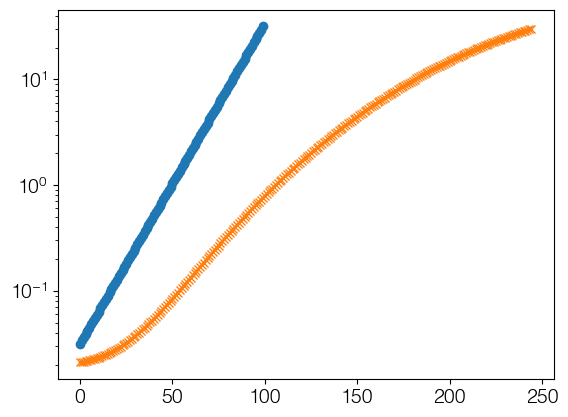

In [171]:
zsquad,_=numrec.GetQuadrature(xmin=1*10**-1.5,xmax=100,N=144*2,quadrature=numrec.TS)
zsquad=zsquad[:len(zsquad)//2]
zsquad = zsquad/zsquad.max()*30
print(len(zsquad))

plt.plot(ProbeGapSpectroscopy.get_coords()/a,marker='o')
plt.plot(zsquad,marker='x')
plt.gca().set_yscale('log')

In [ ]:
gap0 = P.get_a()/5
ProbeGapSpectroscopy2 = PS.ProbeGapSpectroscopyParallel(Probe, gaps=zsquad*P.get_a(), \
                                                         ncpus=8, backend='multiprocessing', \
                                                         Nmodes=50, sommerfeld=False,
                                                         basis_gap=gap0,
                                                         reversed=False)  

We are computing an eigenset at gap=4E-07, and using its first 50 modes as a basis for forthcoming calculations!
Starting gap=4e-07
<ProbeCavityEigenfields.RotationalMoM.ImpedanceMatrix>:
	Preparing quasistatic mirror impedance matrix at k=0...
	Progress: 99.74%	Total quadrature time: 4.90s, time per quadrature evaluation: 3.36E-05s
<ProbeCavityEigenfields.Probe.reset_eigenproperties>:
	Resetting eigenproperties...
Finished gap=4e-07, elapsed time: 5.2 s
Basis will have length 40
<plotting>:
	Registered colormaps "Warm" and "Warm_r"...
<plotting>:
	Registered colormaps "vanheum" and "vanheum_r"...
<plotting>:
	Registered colormaps "NT-MDT" and "NT-MDT_r"...
<plotting>:
<plotting>:
	Registered colormaps "jingdi" and "jingdi_r"...
<plotting>:
	Registered colormaps "Halcyon" and "Halcyon_r"...
<plotting>:
	Registered colormaps "Cold" and "Cold_r"...
<plotting>:
	Registered colormaps "Sky" and "Sky_r"...
<plotting>:
	Registered colormaps "Gwyddion.net" and "Gwyddion.net_r"...
<plotting>:
	

Min gapsize/a in spectroscopy: 0.020963752178270498
Max gapsize/a in spectroscopy: 30.0
N gaps in spectroscpy: 245
Classifying eigensets by eigenindex, with reversal...
	Progress: 99.59%<ProbeCavityEigenfields.ProbeSpectroscopy.ProbeGapSpectroscopyParallel.align_eigencharge_signs>:
	Aligning signage of 20 eigenmode charges over 245 coordinates...


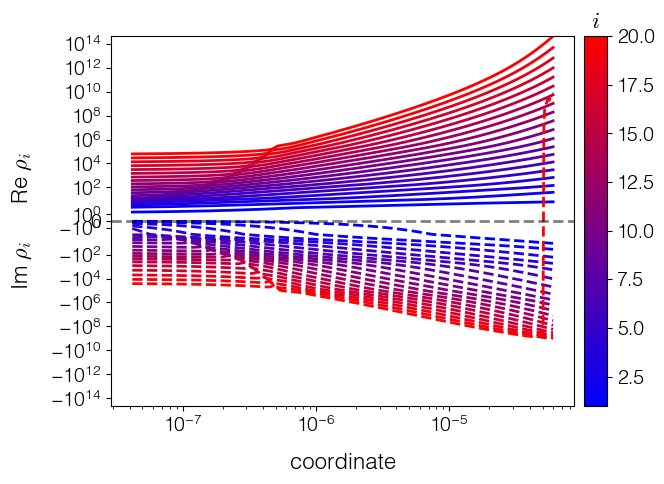

In [206]:

        
print('Min gapsize/a in spectroscopy:',ProbeGapSpectroscopy2.get_coords().min()/P.get_a())
print('Max gapsize/a in spectroscopy:',ProbeGapSpectroscopy2.get_coords().max()/P.get_a())
print('N gaps in spectroscpy:',len(ProbeGapSpectroscopy2.get_coords()))

#--- Classify eigenfields and find range of good modes
Nmodes_classify=20 #sim_kwargs['Nmodes']
ProbeGapSpectroscopy2(Nmodes=Nmodes_classify,reversed=True,by_rho=True,debug=False,coordmax=30*P.get_a())
eigenrhos = ProbeGapSpectroscopy2.get_eigenrhos_AWA()
eigencharges = ProbeGapSpectroscopy2.get_eigencharges_AWA()
ProbeGapSpectroscopy2.plot_eigenrhos(Nmodes=Nmodes_classify)

<ProbeCavityEigenfields.ProbeSpectroscopy.ProbeGapSpectroscopyParallel.get_eigenbrightness_AWA>:
	Computing brightnesses across 245 spectroscopy coordinates...


Text(0.5, 1.0, 'Eigenmode Brightness from ProbeGapSpectroscopy')

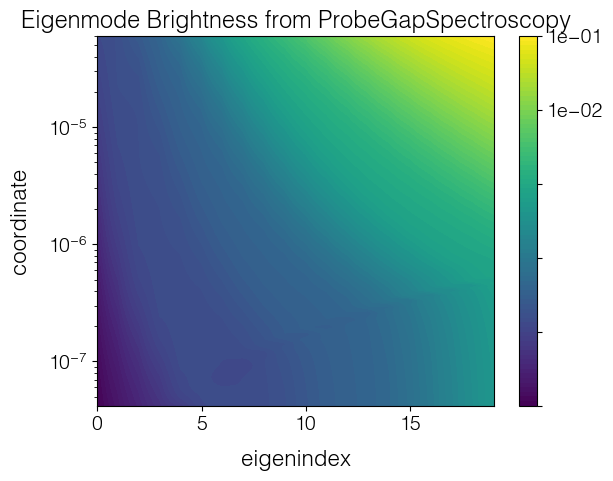

In [207]:
#--- Plot brightness, how many modes are good?
angles=np.linspace(10,90,20)
all_vs = ProbeGapSpectroscopy2.get_eigenbrightness_AWA(angles=angles,verbose=True)
plt.figure()
np.abs(all_vs).plot(plotter=plt.contourf,log_scale=True)
plt.gca().set_yscale('log')
plt.title('Eigenmode Brightness from ProbeGapSpectroscopy')

In [277]:
sim_kwargs['Ngaps']=96 #
sim_kwargs['Nmodes']=30 #
IE = PS.InvertibleEigenfields(ProbeGapSpectroscopy2, Nmodes=sim_kwargs['Nmodes'],
                            interpolation='quadratic',bounds_error=False,fill_value='extrapolate')

# Identify the maximum tapping amplitude, above which we cannot make reliable predictions
amplitude_max = np.array(IE.Rs.axis_limits[0]).max()
print('Maximum tapping amplitude relative to probe radius:',amplitude_max/Probe.get_a()) 
amplitude_max_nm = amplitude_max * sim_kwargs['a_nm']/Probe.get_a()

amplitudes_nm = np.logspace(-1,np.log(amplitude_max_nm)/np.log(10),100)
amplitudes_rel_a = amplitudes_nm/sim_kwargs['a_nm']

q0=1/(sim_kwargs['a_nm']*1e-7)
freq=1000
beta_Si = M.Si.reflection_p(freq,q0)
beta_Au = 1

harmonics=[1,2,3]
s3_vals_Au_vs_Si=[]
s3divs2_vals_Au=[]
s3divs2_vals_Si=[]

for amplitude_nm in amplitudes_nm:
    sim_kwargs['amplitude_nm']=amplitude_nm

    signals_Au_vs_Si = IE.getNormalizedSignal(beta=beta_Si,beta_norm=beta_Au,
                           **sim_kwargs)
    s3_vals_Au_vs_Si.append( [complex(signals_Au_vs_Si['Sn_norm'][n]) for n in harmonics] )
    
    signals_Si = IE.getNormalizedSignal(beta=beta_Si,beta_norm=None,
                           **sim_kwargs)
    s3divs2_vals_Si.append( complex(signals_Si['Sn'][3]) / complex(signals_Si['Sn'][2]) )
    
    signals_Au = IE.getNormalizedSignal(beta=beta_Au,beta_norm=None,
                           **sim_kwargs)
    s3divs2_vals_Au.append( complex(signals_Au['Sn'][3]) / complex(signals_Au['Sn'][2]) )

s3_vals_Au_vs_Si = AWA(s3_vals_Au_vs_Si,
                       axes=[amplitudes_rel_a,harmonics],
                       axis_names=['Tapping amplitude (rel. probe radius)','Harmonic'])

s3divs2_vals_Si = AWA(s3divs2_vals_Si,
                       axes=[amplitudes_rel_a],
                       axis_names=['Tapping amplitude (rel. probe radius)'])

s3divs2_vals_Au = AWA(s3divs2_vals_Au,
                       axes=[amplitudes_rel_a],
                       axis_names=['Tapping amplitude (rel. probe radius)'])

Maximum tapping amplitude relative to probe radius: 30.0
amplitude= 2e-08
gapmin= 2e-07
amplitude= 2e-08
gapmin= 2e-07
amplitude= 2e-08
gapmin= 2e-07
amplitude= 2.1684650786268534e-08
gapmin= 2e-07
amplitude= 2.1684650786268534e-08
gapmin= 2e-07
amplitude= 2.1684650786268534e-08
gapmin= 2e-07
amplitude= 2.3511203986120836e-08
gapmin= 2e-07
amplitude= 2.3511203986120836e-08
gapmin= 2e-07
amplitude= 2.3511203986120836e-08
gapmin= 2e-07
amplitude= 2.5491612400187757e-08
gapmin= 2e-07
amplitude= 2.5491612400187757e-08
gapmin= 2e-07
amplitude= 2.5491612400187757e-08
gapmin= 2e-07
amplitude= 2.7638835643849206e-08
gapmin= 2e-07
amplitude= 2.7638835643849206e-08
gapmin= 2e-07
amplitude= 2.7638835643849206e-08
gapmin= 2e-07
amplitude= 2.996692495379707e-08
gapmin= 2e-07
amplitude= 2.996692495379707e-08
gapmin= 2e-07
amplitude= 2.996692495379707e-08
gapmin= 2e-07
amplitude= 3.2491115138070304e-08
gapmin= 2e-07
amplitude= 3.2491115138070304e-08
gapmin= 2e-07
amplitude= 3.2491115138070304e-08
gap

Text(0, 0.5, '$\\xi$  (Au rel. Si)')

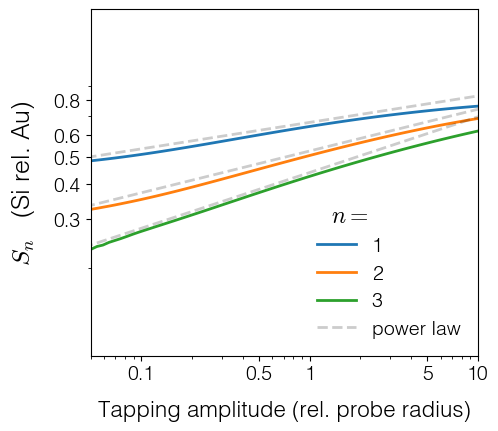

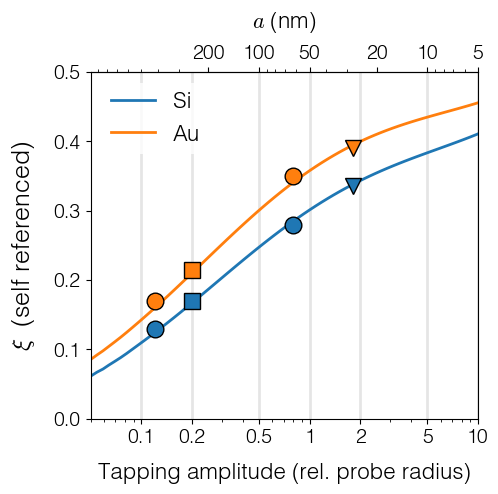

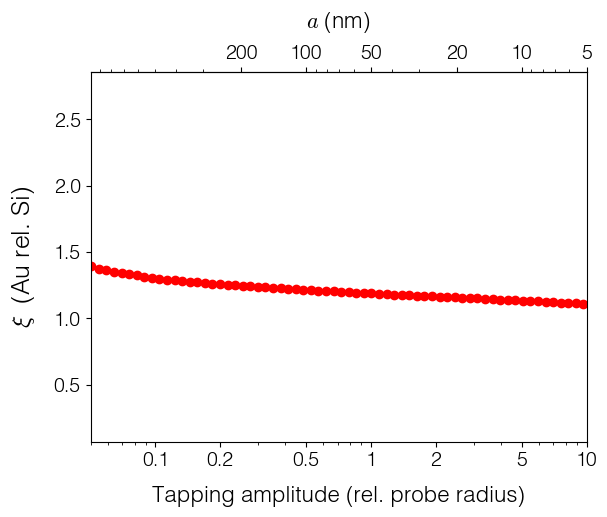

In [279]:

plt.figure(figsize=(5,4.5))
for n in harmonics:
    l,=np.abs(s3_vals_Au_vs_Si.cslice[:,n]).plot(label=n)
    
plt.ylabel('$S_n$   (Si rel. Au)',fontsize=18)
plt.gca().set_xscale('log')
plt.gca().set_yscale('log')
yts=[.3,.4,.5,.6,0.8]
plt.yticks(yts,yts)
gaps = s3_vals_Au_vs_Si.cslice[:,n].axes[0]
pow=.2
plt.plot(gaps,gaps**pow/2.27,ls='--',color='k',alpha=.2)
pow=.15
plt.plot(gaps,gaps**pow/1.9,ls='--',color='k',alpha=.2)
pow=.095
plt.plot(gaps,gaps**pow/1.5,ls='--',color='k',alpha=.2,label='power law')
plt.legend(title='$n=$\t\t',edgecolor='none',loc='lower right',title_fontsize=17)

xts=[0.1,0.5,1,5,10]
plt.xticks(xts,xts)
plt.xlim(.05,10)

plt.figure(figsize=(5,4.5))
l1,=np.abs(s3divs2_vals_Si).plot(label='Si')
l2,=np.abs(s3divs2_vals_Au).plot(label='Au')
plt.ylabel('$S_3/S_2$')
plt.legend(fontsize=16,edgecolor='none')
#plt.yticks([.3,.35,.4,.45,.5])

#plt.twinx()
#np.abs(s3divs2_vals_Si/s3divs2_vals_Au).plot(color='r')

# These are data from "2025.07.18 - Alex - Si-Au nanoFTIR spectroscopy for FreqDepNorm - Tabletop" for sharp PtSi probe
A_norm = 1.8
plt.plot([A_norm],[.335],color=l1.get_color(),marker='v',markeredgecolor='k',ms=12)
plt.plot([A_norm],[.39],color=l2.get_color(),marker='v',markeredgecolor='k',ms=12)


A_norm = .8
plt.plot([A_norm],[.28],color=l1.get_color(),marker='o',markeredgecolor='k',ms=12)
plt.plot([A_norm],[.35],color=l2.get_color(),marker='o',markeredgecolor='k',ms=12)

# These are data from "2025.07.18 - Alex - Si-Au nanoFTIR spectroscopy for FreqDepNorm - Tabletop" for blunt PtIr probe
A_norm = .12
plt.plot([A_norm],[.13],color=l1.get_color(),marker='o',markeredgecolor='k',ms=12)
plt.plot([A_norm],[.17],color=l2.get_color(),marker='o',markeredgecolor='k',ms=12)


# These are data from "2025.08.22 - Alex - Si-Au multichannel nanoFTIR spectroscopy for FreqDepNorm" for bluntish PtSi probe
A_norm = .2
plt.plot([A_norm],[.17],color=l1.get_color(),marker='s',markeredgecolor='k',ms=12)
plt.plot([A_norm],[.215],color=l2.get_color(),marker='s',markeredgecolor='k',ms=12)

plt.gca().set_xscale('log')
plt.xlim(.05,10)
xts=[.1,.2,.5,1,2,5,10]
plt.xticks(xts,xts)

Arel_to_anm = lambda Arel: 50/Arel
anm_to_Arel = lambda anm: 50/anm

xax2=plt.gca().secondary_xaxis('top', functions=(Arel_to_anm, anm_to_Arel))
x2ts=[200,100,50,20,10,5]
xax2.set_xticks(x2ts,x2ts)
xax2.set_xlabel('$a$ (nm)')

plt.ylabel(r'$\xi$  (self referenced)',fontsize=18)


plt.ylim(0,.5)
plt.grid(axis='x',alpha=.1,color='k',lw=2)



plt.figure()
np.abs(s3divs2_vals_Au/s3divs2_vals_Si).plot(color='r',marker='o')
plt.gca().set_xscale('log')
plt.xlim(.05,10)
xts=[.1,.2,.5,1,2,5,10]
plt.xticks(xts,xts)
xax2=plt.gca().secondary_xaxis('top', functions=(Arel_to_anm, anm_to_Arel))
x2ts=[200,100,50,20,10,5]
xax2.set_xticks(x2ts,x2ts)
xax2.set_xlabel('$a$ (nm)')
plt.ylabel(r'$\xi$  (Au rel. Si)',fontsize=18)

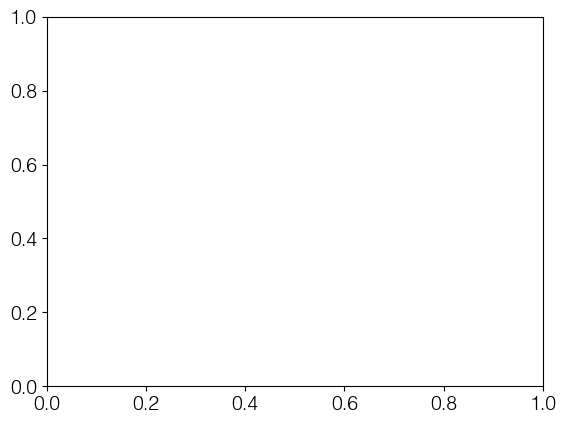

Signature: ax.secondary_xaxis(location, *, functions=None, **kwargs)
Docstring:
Add a second x-axis to this `~.axes.Axes`.

For example if we want to have a second scale for the data plotted on
the xaxis.


Warnings
--------
This method is experimental as of 3.1, and the API may change.

Parameters
----------
location : {'top', 'bottom', 'left', 'right'} or float
    The position to put the secondary axis.  Strings can be 'top' or
    'bottom' for orientation='x' and 'right' or 'left' for
    orientation='y'. A float indicates the relative position on the
    parent axes to put the new axes, 0.0 being the bottom (or left)
    and 1.0 being the top (or right).

functions : 2-tuple of func, or Transform with an inverse

    If a 2-tuple of functions, the user specifies the transform
    function and its inverse.  i.e.
    ``functions=(lambda x: 2 / x, lambda x: 2 / x)`` would be an
    reciprocal transform with a factor of 2. Both functions must accept
    numpy arrays as input.

    The

In [265]:
ax=plt.gca()
ax.secondary_xaxis?